# Taller 4 · Codificación PCM: LPCM, DPCM y Delta Modulation

**Asignatura:** Teoría de la Información y Procesado de Señal  
**Grado en Ciencia e Ingeniería de Datos (GCED) — Universidad de A Coruña**  
**Duración:** 2 horas  
**Modalidad:** Jupyter Notebook con asistencia de IA (GitHub Copilot)

---

## Objetivos de aprendizaje

Al finalizar este taller serás capaz de:

1. Implementar una cadena **LPCM** (cuantificación directa de cada muestra).
2. Implementar **DPCM** con predicción simple y cuantificación del error de predicción.
3. Implementar **Delta Modulation (DM)** y entender sus requisitos de $F_s$.
4. Identificar **granular noise** y **slope overload** en DM.
5. Comparar MSE, SQNR y **régimen binario** entre los tres métodos.
6. Razonar sobre **cuándo cada método es más apropiado**.

---

## Entregables

- Notebook ejecutado completo (**Run All**) sin errores.
- Figuras correctamente etiquetadas (título, ejes, unidades).
- Secciones de **explicación** completadas con razonamiento propio.
- Respuestas a las preguntas de control.

---

## 🎯 Reto central del taller

> **A igualdad de calidad percibida (20~23 dB de SQNR), ¿qué esquema de codificación es más eficiente en términos de tasa binaria y por qué?**
>
> La codificación PCM (Pulse Code Modulation) convierte una señal cuantificada en una secuencia de bits. Pero no todos los esquemas PCM son iguales: algunos explotan la **redundancia temporal** de la señal para ser más eficientes. Este taller compara tres variantes para que lo compruebes experimentalmente.

---

## Metodología de trabajo con IA

En este curso **puedes y debes usar IA**, pero siguiendo estas reglas:

| Qué puede hacer la IA | Qué debes hacer tú |
|----------------------|--------------------|
| Generar código | Entenderlo y validarlo |
| Sugerir implementaciones | Diseñar el experimento |
| Completar sintaxis | Interpretar los resultados |

### Estructura obligatoria de cada bloque

1. **Implementación**: código generado (con o sin IA).
2. **Validación**: al menos un `assert` o comprobación numérica/visual.
3. **Explicación**: 2–5 líneas en tus propias palabras explicando *qué* ocurre y *por qué*.

> **Mensaje clave:** *La IA te ayuda a escribir código, pero no a entender señales. Eso es tu trabajo.*

---

## Identificación del estudiante

Completa los siguientes campos con tu información personal:

- **Apellidos:** `Parcero García`

- **Nombre:** `Clara` 

- **Email UDC:** `clara.parcero@udc.es`

---

## 0. Setup inicial

Ejecuta esta celda para importar las librerías y reutilizar el cuantificador del Taller 3.

In [42]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

# Cuantificador uniforme del Taller 3 (lo reutilizamos)
def cuantificador_uniforme(x, B, xmin, xmax):
    """
    Cuantificador uniforme con REDONDEO (mid-rise).
    x_q, Delta = cuantificador_redondeo(x, B, xmin, xmax)
    
    x: valor de entrada
    B: número de bits
    xmin, xmax: rango de cuantificación
    x_q: valor cuantificado""" 

    rango = xmax - xmin
    L= 2 ** B
    Delta = rango / L

    l = np.floor((x - xmin) / Delta).astype(int)
    l = np.clip(l, 0, L - 1) # Asegura que l esté dentro del rango válido [0, L-1]
    
    x_q = l * Delta + xmin + Delta / 2

    return x_q, Delta

# Función para calcular MSE y SQNR
def calcular_metricas(x_orig, x_q):
    """Calcula MSE y SQNR entre señal original y reconstruida."""
    e = x_orig - x_q
    MSE = np.mean(e**2)
    P_x = np.mean(x_orig**2)
    SQNR_db = 10 * np.log10(P_x / MSE) if MSE > 0 else np.inf
    return MSE, SQNR_db

print("✓ Entorno listo (incluye funciones de cuantificador del Taller 3 y de cálculo de métricas).")

✓ Entorno listo (incluye funciones de cuantificador del Taller 3 y de cálculo de métricas).


---

## Contexto teórico: La familia PCM

La conversión analógico-digital (ADC) tiene tres etapas:

$$x_a(t) \xrightarrow{\text{Muestreo}} x(n) \xrightarrow{\text{Cuantificación}} x_q(n) \xrightarrow{\text{Codificación}} \text{bits}$$

En el Taller 3 estudiamos la cuantificación. Ahora nos centramos en **cómo codificar** las muestras cuantificadas en bits. La familia **PCM** (Pulse Code Modulation) agrupa varios métodos:

| Método | ¿Qué cuantifica? | Bits/muestra | Explota correlación |
|--------|-------------------|--------------|---------------------|
| **LPCM** | Cada muestra directamente | $B$ | No |
| **DPCM** | La diferencia $d[n] = x[n] - \hat{x}[n]$ | $B$ | Sí |
| **DM** | Solo el signo del error (subir/bajar) | 1 | Sí (extremo) |

**Idea clave:** Si la señal tiene **correlación temporal** (muestras consecutivas parecidas), el error de predicción tiene menor rango que la señal original. Cuantificar ese error con los mismos $B$ bits da **mejor calidad**.

**Régimen binario:** $R_b = B \cdot F_s$ bits/segundo. A menor $B$ (o menor $F_s$), menor ancho de banda necesario.

---

## Parte 1: Señales de partida

### Bloque 1 · Generación de señal compuesta

---

#### 📝 Hipótesis previa (COMPLETA ANTES de implementar/ejecutar)

**Preguntas:**

- Si las muestras consecutivas se parecen mucho (alta correlación), ¿qué método se beneficiaría? `DPCM, porque funciona mejor cuando las muestras consecutivas son parecidas porque codifica la diferencia entre muestras, que será pequeña.`
- ¿Una señal compuesta por la suma de dos sinusoidales tendrá más o menos correlación temporal que ruido blanco? `Más, porque las sinusoides cambian de forma suave, por lo que sus valores consecutivos son similares, mientras que el ruido blanco es aleatorio y casi no tiene correlación temporal.`

---

**Parámetros:**
- Señal compuesta por la suma de dos señales seno con frecuencias: $F_1 = 2$ Hz, $F_2 = 7$ Hz y amplitudes $A_1 = 1$, $A_2 = 0.5$.
- Duración: 2 segundos
- Escalar para que $\max|x| = 0.9$

**Tareas:**
1. Genera dos versiones discretas de la señal compuesta (suma de dos sinusoides) con frecuencias de muestreo $F_s = 100$ Hz y $F_s = 400$ Hz.
2. Escala al rango adecuado para evitar saturación.
3. Represéntala.

In [43]:
# === PARÁMETROS ===
F_s100=100
F_s400=400

# Parámetros de la señal compuesta
T = 2             # segundos
F1, F2 = 2, 7     # Hz
A1, A2 = 1.0, 0.5 # Amplitudes

In [44]:
# N_100, N_400: número de muestras, para Fs=100 Hz y Fs=400 Hz respectivamente
# n_100, n_400: vector de índices de muestra, para Fs=100 Hz y Fs=400 Hz respectivamente
N_100 = int(F_s100 * T)
n_100 = np.arange(N_100)
N_400 = int(F_s400 * T)
n_400 = np.arange(N_400)

# TODO: Genera las señales compuestas (suma de dos sinusoides),
# x_raw100 y x_raw400 con Fs=100 Hz y Fs=400 Hz respectivamente.
x_raw100 = A1*np.sin(2*np.pi*F1*n_100/F_s100) + A2*np.sin(2*np.pi*F2*n_100/F_s100)
x_raw400 = A1*np.sin(2*np.pi*F1*n_400/F_s400) + A2*np.sin(2*np.pi*F2*n_400/F_s400)

# TODO: Escala para obtener señal x_100 y x_400, con max(|x_100|) = max(|x_400|) = 0.9
x_100 = 0.9 * x_raw100 / np.max(np.abs(x_raw100))
x_400 = 0.9 * x_raw400 / np.max(np.abs(x_raw400))

✓ Señal de 2 segundos generada con F_s=100: 200 muestras, rango [-0.900, 0.900]
✓ Señal de 2 segundos generada con F_s=400: 800 muestras, rango [-0.900, 0.900]


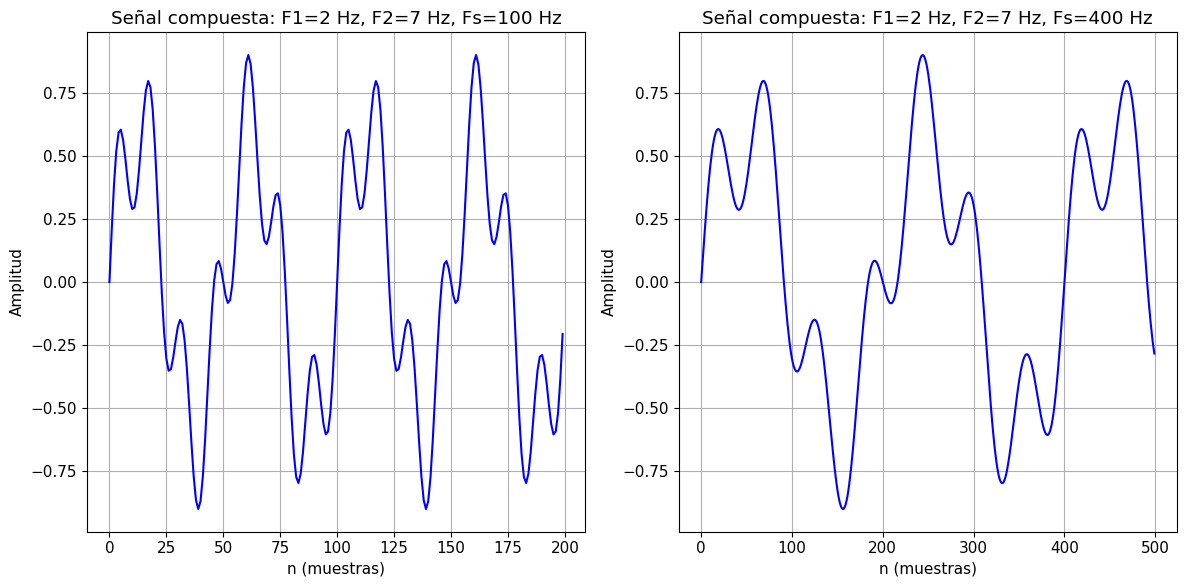

In [45]:
# === VALIDACIÓN ===
assert x_100 is not None, "Genera la señal x_100"
assert x_400 is not None, "Genera la señal x_400"
assert len(x_100) == N_100 and len(x_400) == N_400, f"Las señales debe tener {N_100} y {N_400} muestras"
assert np.max(np.abs(x_100)) <= 0.9001, f"La amplitud máxima debe ser ≤ 0.9, es {np.max(np.abs(x_100)):.3f}"
assert np.max(np.abs(x_400)) <= 0.9001, f"La amplitud máxima debe ser ≤ 0.9, es {np.max(np.abs(x_400)):.3f}"
assert np.max(np.abs(x_100)) > 0.89, "La señal debe estar escalada para max ≈ 0.9"
assert np.max(np.abs(x_400)) > 0.89, "La señal debe estar escalada para max ≈ 0.9"

print(f"✓ Señal de {T} segundos generada con F_s={F_s100}: {N_100} muestras, rango [{np.min(x_100):.3f}, {np.max(x_100):.3f}]")
print(f"✓ Señal de {T} segundos generada con F_s={F_s400}: {N_400} muestras, rango [{np.min(x_400):.3f}, {np.max(x_400):.3f}]") 

# Representa

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(n_100[:500], x_100[:500], 'b-')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.title(f'Señal compuesta: F1={F1} Hz, F2={F2} Hz, Fs={F_s100} Hz')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n_400[:500], x_400[:500], 'b-')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.title(f'Señal compuesta: F1={F1} Hz, F2={F2} Hz, Fs={F_s400} Hz')
plt.grid(True)

plt.tight_layout()
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Por qué una señal compuesta (con correlación temporal) es útil para comparar métodos PCM?**

*Tu respuesta:*

```
Porque permite ver mejor las diferencias entre los métodos de codificación. Cuando una señal tiene correlación temporal, las muestras consecutivas son parecidas, lo que hace que métodos como DPCM o DM, que trabajan con diferencias entre muestras, funcionen de forma más eficiente que el LPCM. 
```

**2. ¿Qué significa "correlación temporal" intuitivamente? ¿Las muestras consecutivas de esta señal se parecen?**

*Tu respuesta:*

```
La correlación temporal significa que los valores de la señal en instantes cercanos están relacionados entre sí. Es decir, si una muestra tiene un valor determinado, la siguiente probablemente tendrá un valor parecido. 
Sí, en esta señal las muestras consecutivas se parecen porque está formada por sinusoides, que cambian de forma suave con el tiempo.
```

### 🔍 Checkpoint del profesor (Parada 1)

- [ ] Señal compuesta generada, escalada a $\pm 0.9$
- [ ] Assert pasando sin errores

---

## Parte 2: LPCM (Linear PCM) — Cuantificación directa

### Contexto teórico

LPCM cuantifica **cada muestra independientemente** usando $B$ bits:
- No tiene en cuenta el valor de muestras anteriores ni posteriores
- Régimen binario: $R_b = B \cdot F_s$ bits/segundo
- Es el método más simple pero **no explota la correlación temporal**

**Ejemplo real:** El audio en formato WAV sin comprimir usa LPCM (16 bits, 44100 Hz → $R_b = 705{,}600$ bits/s por canal).

### Bloque 2 · Implementación de LPCM

---

#### 📝 Hipótesis previa

**Pregunta:** Con $B = 4$ bits 
- ¿Régimen binario para cada señal?: `Rb = BxFs; para Fs=100Hz -> Rb=4x100=400 bits/s y para Fs=400Hz -> Rb=4x400=1600 bits/s `

---

**Tareas:**
1. Cuantifica las señales, con las dos frecuencias de muestreo anteriores, con el cuantificador uniforme (ya implementado en el setup).
2. Calcula los regímenes binarios R_b_100 y R_b_200, para cada señal respectivamente.
3. Calcula MSE_100 y MSE_400, para cada señal respectivamente.
4. Calcula SQNR_100 y SQNR_400, para cada señal respectivamente.
4. Representa las señales originales vs la cuantificadas (zoom de 200 muestras).

In [46]:
# === IMPLEMENTACIÓN ===
B_lpcm_100 = B_lpcm_400 = 4  # bits

# TODO: Calcula el régimen binario, Rb_lpcm_100 y Rb_lpcm_400, para el cuantificador uniforme con B=4 bits
Rb_lpcm_100 = B_lpcm_100 * F_s100  # bits/s
Rb_lpcm_400 = B_lpcm_400 * F_s400  # bits/s

print(f"Régimen binario LPCM 100 Hz: {Rb_lpcm_100} bits/s")
print(f"Régimen binario LPCM 400 Hz: {Rb_lpcm_400} bits/s")

# TODO: Cuantifica la señal x_100 usando cuantificador_uniforme y su error de cuantización, x_lpcm_100, Delta_lpcm_100, e_lpcm_100
# Cuantifica x_400 usando cuantificador_uniforme y su error de cuantización, x_lpcm_400, Delta_lpcm_400, e_lpcm_400
# Señal x_100
xmin_100, xmax_100 = np.min(x_100), np.max(x_100)
x_lpcm_100, Delta_lpcm_100 = cuantificador_uniforme(x_100, B_lpcm_100, xmin_100, xmax_100)
e_lpcm_100 = x_100 - x_lpcm_100

# Señal x_400
xmin_400, xmax_400 = np.min(x_400), np.max(x_400)
x_lpcm_400, Delta_lpcm_400 = cuantificador_uniforme(x_400, B_lpcm_400, xmin_400, xmax_400)
e_lpcm_400 = x_400 - x_lpcm_400

# TODO: Calcula el MSE y la SQNR para x_100 y x_400, usando la función calcular_metricas
# MSE_lpcm_100, SQNR_lpcm_100, MSE_lpcm_400, SQNR_lpcm_400, según se trate de las señales x_100 o x_400
MSE_lpcm_100, SQNR_lpcm_100 = calcular_metricas(x_100, x_lpcm_100)
MSE_lpcm_400, SQNR_lpcm_400 = calcular_metricas(x_400, x_lpcm_400)

print(f"LPCM 100 Hz → MSE: {MSE_lpcm_100:.5f}, SQNR: {SQNR_lpcm_100:.2f} dB")
print(f"LPCM 400 Hz → MSE: {MSE_lpcm_400:.5f}, SQNR: {SQNR_lpcm_400:.2f} dB")

Régimen binario LPCM 100 Hz: 400 bits/s
Régimen binario LPCM 400 Hz: 1600 bits/s
LPCM 100 Hz → MSE: 0.00128, SQNR: 22.57 dB
LPCM 400 Hz → MSE: 0.00109, SQNR: 23.28 dB


In [47]:
# === VALIDACIÓN ===
assert x_lpcm_100 is not None, "Cuantifica la señal x_100"
assert x_lpcm_400 is not None, "Cuantifica la señal x_400"
assert Rb_lpcm_100 == B_lpcm_100 * F_s100, f"Régimen binario incorrecto: {Rb_lpcm_100} bits/s, debe ser {B_lpcm_100 * F_s100} bits/s"
assert Rb_lpcm_400 == B_lpcm_400 * F_s400, f"Régimen binario incorrecto: {Rb_lpcm_400} bits/s, debe ser {B_lpcm_400 * F_s400} bits/s"
assert MSE_lpcm_100 is not None and MSE_lpcm_100 > 0, "Calcula el MSE de x_100"
assert SQNR_lpcm_100 is not None and SQNR_lpcm_100 > 0, "Calcula la SQNR de x_100"
assert MSE_lpcm_400 is not None and MSE_lpcm_400 > 0, "Calcula el MSE de x_400"
assert SQNR_lpcm_400 is not None and SQNR_lpcm_400 > 0, "Calcula la SQNR de x_400"

print(f"=== LPCM (B={B_lpcm_100} bits) para x_100 ===")
print(f"Δ = {Delta_lpcm_100:.4f}")
print(f"MSE: {MSE_lpcm_100:.6f}")
print(f"SQNR: {SQNR_lpcm_100:.2f} dB")
print(f"Régimen binario: {Rb_lpcm_100} bits/s")
print("")
print(f"=== LPCM (B={B_lpcm_400} bits) para x_400 ===")
print(f"Δ = {Delta_lpcm_400:.4f}")
print(f"MSE: {MSE_lpcm_400:.6f}")
print(f"SQNR: {SQNR_lpcm_400:.2f} dB")
print(f"Régimen binario: {Rb_lpcm_400} bits/s")

=== LPCM (B=4 bits) para x_100 ===
Δ = 0.1125
MSE: 0.001281
SQNR: 22.57 dB
Régimen binario: 400 bits/s

=== LPCM (B=4 bits) para x_400 ===
Δ = 0.1125
MSE: 0.001088
SQNR: 23.28 dB
Régimen binario: 1600 bits/s


### ✍️ Explicación (OBLIGATORIA)

**1. ¿Ves alguna diferencia importante al cuantificar las señales x_100 y x_400 con LPCM? Da una explicación.**

*Tu respuesta:*

```
No hay una diferencia significativa en la cuantización porque LPCM trata cada muestra de forma independiente. 
La única diferencia es que x_400 tiene más muestras por segundo, por lo que el régimen binario es mayor, pero la precisión de cada muestra (Δ, MSE, SQNR) es muy similar a la de x_100.
```

---

## Parte 3: DPCM (Differential PCM) — Cuantificación del error de predicción

### Contexto teórico

DPCM explota la **correlación temporal** de la señal:

1. **Predice** la muestra actual a partir de las anteriores: $\hat{x}[n] = x_q[n-1]$ (predictor orden 1)
2. **Calcula** la diferencia: $d[n] = x[n] - \hat{x}[n]$
3. **Cuantifica** la diferencia (que tiene rango dinámico menor que la señal): $d_q[n] = Q[d[n]]$
4. **Reconstruye** en el decodificador: $x_q[n] = \hat{x}[n] + d_q[n]$

NOTA: en ocasiones, la diferencia, $d(n)$, se interpreta como un error de predicción, ya que, en el fondo, se trata del error que comete la predicción $\hat{x}[n]$ respecto a la señal original $x(n)$ . No confundamos esta denominación de la señal diferencia con el error de cuantificación, que es la señal $e(n)$ que ya conocemos.

**¿Por qué funciona?** Si la señal varía lentamente (alta correlación), el error de predicción $d[n]$ es pequeño. Cuantificar un valor pequeño con los mismos $B$ bits da **menor error de cuantificación** → mejor SQNR.

En el decodificador se usa $x_q[n-1]$ (la muestra cuantificada o reconstruida), NO $x[n-1]$ (la original). Esto evita que el error se acumule sin control (el codificador y decodificador "ven" lo mismo).

| Variable | Codificador | Decodificador |
|----------|-------------|---------------|
| Predicción | $\hat{x}[n] = x_q[n-1]$ | $\hat{x}[n] = x_q[n-1]$ |
| Diferencia | $d[n] = x[n] - \hat{x}[n]$ | (recibe $d_q[n]$) |
| Reconstrucción | $x_q[n] = \hat{x}[n] + d_q[n]$ | $x_q[n] = \hat{x}[n] + d_q[n]$ |

### Bloque 3 · Implementación de DPCM

---

#### 📝 Hipótesis previa

**Pregunta:** Si la señal cambia de forma "suave" (muestras consecutivas parecidas):
- La diferencia $d[n] = x[n] - x[n-1]$ será ¿grande o pequeño? `pequeña`
- ¿Necesitarás más o menos rango para cuantificar $d[n]$ comparado con $x[n]$? `menos rango`
- A igualdad de bits, ¿DPCM debería dar mejor o peor SQNR que LPCM? `mejor`

---

**Tareas:**
1. Implementa el bucle de DPCM (predictor de orden 1).
2. Elige un rango adecuado para cuantificar de la señal diferencia.
3. Calcula métricas y compara con LPCM.

**Pistas:**
- En la primera muestra ($n = 0$), vamos a suponer que la predicción es $\hat{x}[0] = 0$.
- El rango del cuantificador de la diferencia se puede estimar como: `d_range = max(|diff(x)|) * 1.5`
- Usa el `cuantificador_uniforme` del setup con `xmin=-d_range, xmax=d_range`.

In [48]:
# === Parámetros ===
B_dpcm_100 = B_dpcm_400 = 2

In [49]:
# === IMPLEMENTACIÓN ===
def dpcm_encode_decode(x, B):
    """
    DPCM con predictor de orden 1: x_hat[n] = x_rec[n-1]
    
    Parámetros:
        x: señal original
        B: bits para cuantificar el error
    
    Retorna:
        x_q: señal reconstruida
        d_range: rango usado
    """
    N = len(x)
    x_q = np.zeros(N)
    
    # TODO: Estimar rango de la señal diferencia y considera que el rango estará dentro de [-d_range, d_range)
    # donde d_range = max(|x[n] - x[n-1]|) * 1.5
    diff = np.diff(x, prepend=x[0])  # diferencia con x[-1] = x[0] para inicializar
    d_range = 1.5 * np.max(np.abs(diff))  # factor 1.5 para evitar saturación
    
    
    for i in range(N):
        # TODO: Implementa el bucle DPCM
        # 1. Predicción: x_hat = x_q[i-1] (o 0 si i==0)
        x_hat = x_q[i-1] if i > 0 else 0
        # 2. Error de predicción: d = x[i] - x_hat
        d = x[i] - x_hat
        # 3. Cuantifica uniformemente con rendondeo, haciendo uso de la función de cuantificación anterior
        d_q, Delta = cuantificador_uniforme(d, B, -d_range, d_range)
        # 4. Reconstruye: x_q[i] = x_hat + d_q
        x_q[i] = x_hat + d_q

     
    return x_q, d_range


In [50]:
# TODO: Calcula el régimen binario, Rb_dpcm_100 y Rb_dpcm_400, para el cuantificador uniforme con B=2 bits
Rb_dpcm_100 = B_dpcm_100 * F_s100  # bits/s
Rb_dpcm_400 = B_dpcm_400 * F_s400  # bits/s

print(f"Régimen binario DPCM 100 Hz: {Rb_dpcm_100} bits/s")
print(f"Régimen binario DPCM 400 Hz: {Rb_dpcm_400} bits/s")

# TODO: Ejecuta DPCM sobre las señales x_100 y x_400, obteniendo x_dpcm_100, d_range_used_100, x_dpcm_400, d_range_used_400
# Señal x_100
x_dpcm_100, d_range_used_100 = dpcm_encode_decode(x_100, B_dpcm_100)

# Señal x_400
x_dpcm_400, d_range_used_400 = dpcm_encode_decode(x_400, B_dpcm_400)

# TODO: Calcula el MSE y la SQNR para x_100 y x_400, usando la función calcular_metricas
MSE_dpcm_100, SQNR_dpcm_100 = calcular_metricas(x_100, x_dpcm_100)
MSE_dpcm_400, SQNR_dpcm_400 = calcular_metricas(x_400, x_dpcm_400)

print(f"DPCM x_100 → MSE: {MSE_dpcm_100:.6f}, SQNR: {SQNR_dpcm_100:.2f} dB, rango usado: {d_range_used_100:.3f}")
print(f"DPCM x_400 → MSE: {MSE_dpcm_400:.6f}, SQNR: {SQNR_dpcm_400:.2f} dB, rango usado: {d_range_used_400:.3f}")

Régimen binario DPCM 100 Hz: 200 bits/s
Régimen binario DPCM 400 Hz: 800 bits/s
DPCM x_100 → MSE: 0.002068, SQNR: 20.49 dB, rango usado: 0.309
DPCM x_400 → MSE: 0.000136, SQNR: 32.33 dB, rango usado: 0.079


In [51]:
# === VALIDACIÓN ===
assert len(x_dpcm_100) == len(x_100), "La señal DPCM debe tener la misma longitud"
assert len(x_dpcm_400) == len(x_400), "La señal DPCM debe tener la misma longitud"
assert np.all(np.isfinite(x_dpcm_100)), "La señal DPCM no debe contener NaN o Inf"
assert np.all(np.isfinite(x_dpcm_400)), "La señal DPCM no debe contener NaN o Inf"
assert MSE_dpcm_100 > 0, "El MSE debe ser positivo"
assert MSE_dpcm_400 > 0, "El MSE debe ser positivo"

print(f"=== DPCM (B={B_dpcm_100} bits) para x_100 ===")
print(f"MSE: {MSE_dpcm_100:.6f}")
print(f"SQNR: {SQNR_dpcm_100:.2f} dB")
print(f"Régimen binario: {Rb_dpcm_100} bits/s")
print("")
print(f"=== DPCM (B={B_dpcm_400} bits) para x_400 ===")
print(f"MSE: {MSE_dpcm_400:.6f}")
print(f"SQNR: {SQNR_dpcm_400:.2f} dB")
print(f"Régimen binario: {Rb_dpcm_400} bits/s")


=== DPCM (B=2 bits) para x_100 ===
MSE: 0.002068
SQNR: 20.49 dB
Régimen binario: 200 bits/s

=== DPCM (B=2 bits) para x_400 ===
MSE: 0.000136
SQNR: 32.33 dB
Régimen binario: 800 bits/s


### ✍️ Explicación (OBLIGATORIA)

**1. ¿Ves alguna diferencia al cuantificar las señales x_100 y x_400 con DPCM? Da una explicación.**

*Tu respuesta:*

```
Con DPCM, la diferencia entre muestras consecutivas es pequeña, por lo que el error de cuantización es menor que en LPCM. 
Entre x_100 y x_400 no hay diferencias importantes en la calidad de cada muestra, pero x_400 transmite más muestras por segundo, aumentando el régimen binario. 
En ambos casos, DPCM mejora la SQNR respecto a LPCM usando los mismos bits por muestra.
```

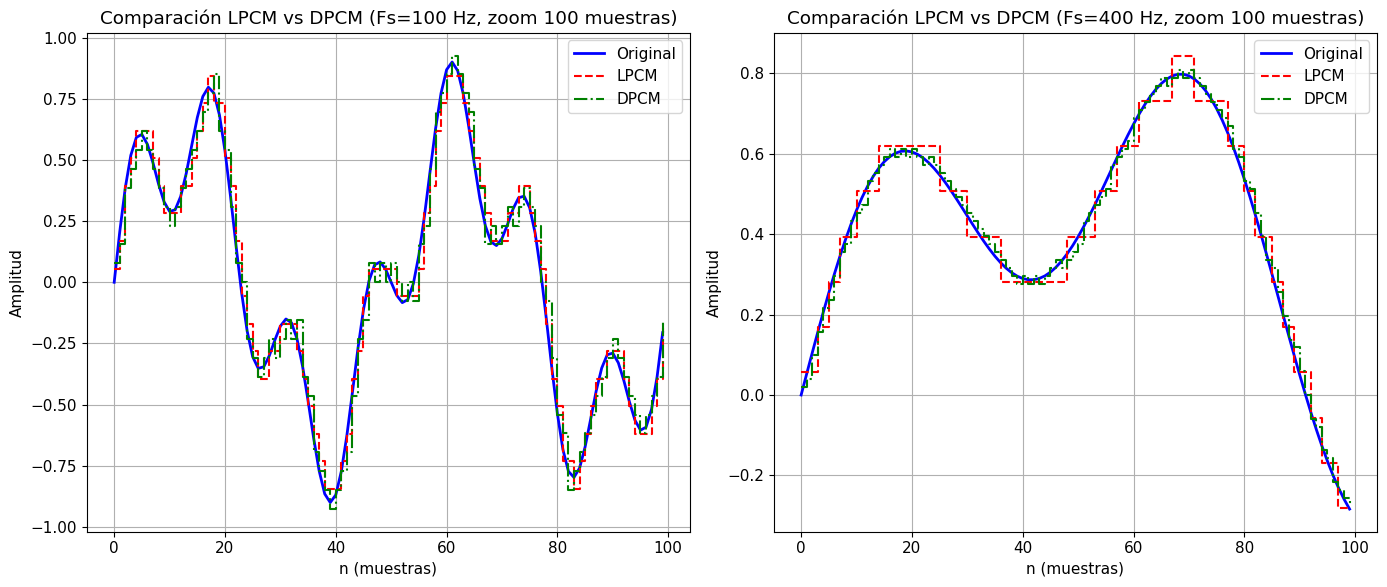

In [52]:
# Visualización comparativa (primeras 100 muestras) superponiendo en la misma gráfica la señal original x (con plot normal) y
# x_lpcm y x_dpcm (plot con drawstyle="steps-post"))
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(n_100[:100], x_100[:100], 'b-', label='Original', linewidth=2)
plt.plot(n_100[:100], x_lpcm_100[:100], 'r--', label='LPCM', drawstyle="steps-post", linewidth=1.5)
plt.plot(n_100[:100], x_dpcm_100[:100], 'g-.', label='DPCM', drawstyle="steps-post", linewidth=1.5)
plt.title(f'Comparación LPCM vs DPCM (Fs={F_s100} Hz, zoom 100 muestras)')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n_400[:100], x_400[:100], 'b-', label='Original', linewidth=2)
plt.plot(n_400[:100], x_lpcm_400[:100], 'r--', label='LPCM', drawstyle="steps-post", linewidth=1.5)
plt.plot(n_400[:100], x_dpcm_400[:100], 'g-.', label='DPCM', drawstyle="steps-post", linewidth=1.5)
plt.title(f'Comparación LPCM vs DPCM (Fs={F_s400} Hz, zoom 100 muestras)')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. ¿DPCM es mejor a LPCM? Razona la respuesta.**

*Tu respuesta:*

```
Sí, DPCM es mejor que LPCM cuando la señal tiene alta correlación temporal. 
Al cuantificar la diferencia entre muestras consecutivas (que suele ser pequeña), el error de cuantización disminuye, aumentando la SQNR respecto a LPCM usando los mismos bits por muestra. 
En las gráficas se ve que DPCM sigue más fielmente la forma de la señal original.
```

**2. ¿Qué rango elegiste para cuantificar la señal diferencia y por qué es menor que el rango de la señal?**

*Tu respuesta:*

```
Se eligió un rango aproximadamente +- 1.5 veces el máximo de las diferencias entre muestras consecutivas. 
Es menor que el rango de la señal original porque las diferencias son mucho más pequeñas que los valores absolutos de la señal, lo que permite usar la misma cantidad de bits con mayor precisión.
```

**3. ¿Beneficia tener una frecuencia de muestreo más alta (400 Hz) en DPCM? Razona la respuesta.**


*Tu respuesta:*

```
Sí, porque al tener una frecuencia de muestreo más alta las muestras consecutivas se parecen más entre sí. 
Esto hace que la diferencia entre muestras sea más pequeña, por lo que DPCM puede cuantificar el error con mayor precisión y mejorar la SQNR.
```


**4. ¿Cuándo DPCM podría empeorar respecto a LPCM? (Pista: piensa en señales sin correlación temporal)**

*Tu respuesta:*

```
DPCM puede empeorar respecto a LPCM cuando la señal no tiene correlación temporal, como en el caso del ruido blanco. 
En estas señales, las muestras consecutivas no se parecen entre sí, por lo que la diferencia entre muestras puede ser grande. 
Esto hace que la predicción sea poco útil y el error de cuantización pueda aumentar.
```

### 🔍 Checkpoint del profesor (Parada 2)

- [ ] LPCM y DPCM implementados con diferente número de bits
- [ ] Métricas calculadas: MSE, SQNR, Rb
- [ ] DPCM muestra ventaja sobre LPCM
- [ ] Explicación de por qué DPCM es mejor para señales correlacionadas

---

## Parte 4: Delta Modulation (DM) — DPCM de 1 bit

### Contexto teórico

Delta Modulation es un caso extremo de DPCM:
- **Solo 1 bit** por muestra: 1 = subir, 0 = bajar
- Paso fijo $\Delta$ (cuánto sube o baja en cada muestra)
- Régimen binario: $R_b = 1 \times F_s = F_s$ bits/segundo (**mucho menor**)
- Predictor acumulativo: $x_q[n] = x_q[n-1] \pm \Delta$

**Problemas típicos:**

| Problema | Causa | Efecto visual |
|----------|-------|---------------|
| **Granular noise** | $\Delta$ muy grande | Oscilación en zonas planas |
| **Slope overload** | $\Delta$ muy pequeño | No puede seguir cambios rápidos |

### Bloque 4 · Implementación de Delta Modulation

---

#### 📝 Hipótesis previa

**Pregunta:** DM usa solo 1 bit por muestra (subir o bajar $\Delta$). Piensa en:
- Si $\Delta$ es muy grande, ¿qué le pasa a la señal reconstruida en zonas donde la señal es constante? `la señal reconstruida oscila alrededor de la señal original`
- Si $\Delta$ es muy pequeño, ¿qué le pasa cuando la señal sube rápidamente? `la señal reconstruida no puede seguir cambios rápidos de la señal`
- ¿Existirá un valor "perfecto" de $\Delta$? `no, porque debe equilibrar seguir cambios rápidos y evitar oscilaciones en zonas planas`

---

**Tareas:**
1. Implementa el bucle de DM.
2. Estima un buen valor de $\Delta$ basándote en la pendiente máxima de la señal.
3. Calcula métricas y régimen binario.

In [53]:
# === IMPLEMENTACIÓN ===
def delta_modulation(x, delta):
    """
    Delta Modulation con paso fijo.
    
    Parámetros:
        x: señal original
        delta: paso de cuantificación (cuánto sube o baja)
    
    Retorna:
        x_q: señal reconstruida
        bits: secuencia de bits (1 = subir, 0 = bajar)
    """
    N = len(x)
    x_q = np.zeros(N)
    bits = np.zeros(N, dtype=int)
    
    for i in range(N):
        # TODO: Implementa DM
        # 1. x_prev = x_q[i-1] (o 0 si i==0)
        if i== 0:
            x_prev = 0
        else:
            x_prev = x_q[i-1]
        # 2. Si x[i] >= x_prev: bit=1, x_rec[i] = x_prev + delta
        if x[i] >= x_prev:
            bits[i] = 1
            x_q[i] = x_prev + delta
        # 3. Si x[i] < x_prev:  bit=0, x_rec[i] = x_prev - delta
        else:
            bits[i] = 0
            x_q[i] = x_prev - delta

    
    return x_q, bits

In [54]:
delta_dm_100 = delta_dm_400 = 0.04

# TODO: Calcula el régimen binario, Rb_dm_100 y Rb_dm_400 (DM usa 1 bit por muestra)
Rb_dm_100 = F_s100 * 1
Rb_dm_400 = F_s400 * 1

# TODO: Cuantifica con DM y calcula MSE y SQNR para x_100 y x_400, obteniendo x_dm_100, bits_dm_100, MSE_dm_100, SQNR_dm_100, x_dm_400, bits_dm_400, MSE_dm_400, SQNR_dm_400
# Cuantificación con DM
x_dm_100, bits_dm_100 = delta_modulation(x_100, delta_dm_100)
x_dm_400, bits_dm_400 = delta_modulation(x_400, delta_dm_400)

# MSE
MSE_dm_100 = np.mean((x_100 - x_dm_100)**2)
MSE_dm_400 = np.mean((x_400 - x_dm_400)**2)

# SQNR
SQNR_dm_100 = 10 * np.log10(np.mean(x_100**2) / MSE_dm_100)
SQNR_dm_400 = 10 * np.log10(np.mean(x_400**2) / MSE_dm_400)

In [55]:
# === VALIDACIÓN ===
assert len(x_dm_100) == len(x_100), "La señal DM debe tener la misma longitud"
assert len(x_dm_400) == len(x_400), "La señal DM debe tener la misma longitud"
assert np.all(np.isfinite(x_dm_100)), "La señal DM no debe contener NaN o Inf"
assert np.all(np.isfinite(x_dm_400)), "La señal DM no debe contener NaN o Inf"
assert Rb_dm_100 == F_s100, "El régimen binario de DM debe ser Fs"
assert Rb_dm_400 == F_s400, "El régimen binario de DM debe ser Fs"

print(f"\n=== Delta Modulation para x_100 ===")
print(f"Régimen binario: {Rb_dm_100} bits/s")
print(f"Delta elegido: {delta_dm_100:.4f}")
print(f"MSE DM: {MSE_dm_100:.6f}")
print(f"SQNR DM: {SQNR_dm_100:.2f} dB")
print("")
print(f"=== Delta Modulation para x_400 ===")
print(f"Régimen binario: {Rb_dm_400} bits/s")
print(f"Delta elegido: {delta_dm_400:.4f}")
print(f"MSE DM: {MSE_dm_400:.6f}")
print(f"SQNR DM: {SQNR_dm_400:.2f} dB")


=== Delta Modulation para x_100 ===
Régimen binario: 100 bits/s
Delta elegido: 0.0400
MSE DM: 0.146370
SQNR DM: 1.99 dB

=== Delta Modulation para x_400 ===
Régimen binario: 400 bits/s
Delta elegido: 0.0400
MSE DM: 0.000971
SQNR DM: 23.77 dB


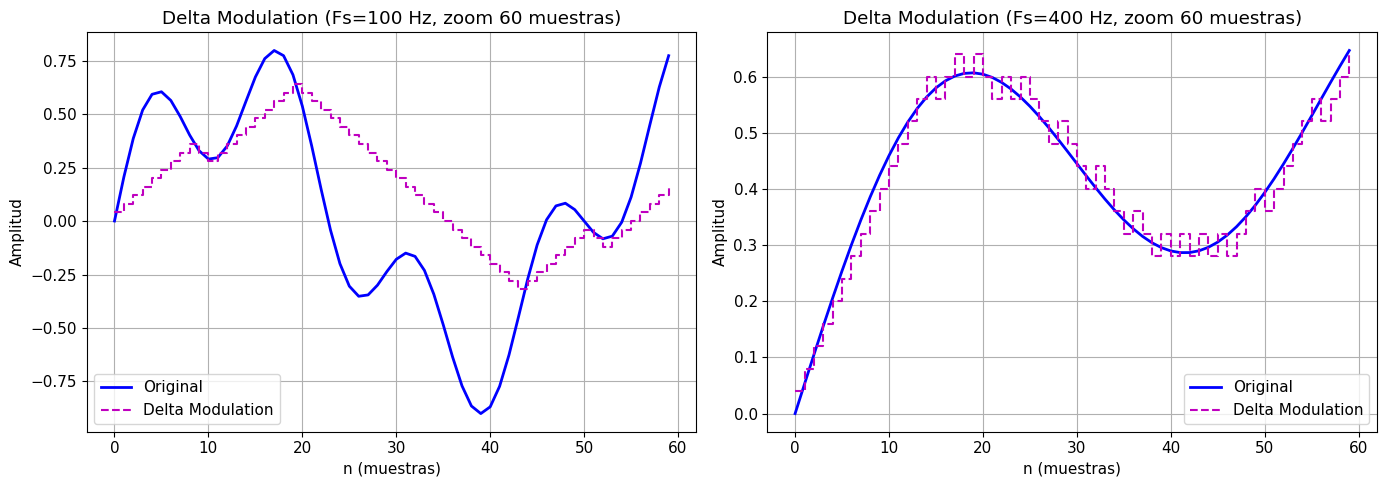

In [56]:
# Visualización (zoom de 60 muestras)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(n_100[:60], x_100[:60], 'b-', label='Original', linewidth=2)
plt.plot(n_100[:60], x_dm_100[:60], 'm--', label='Delta Modulation', drawstyle="steps-post", linewidth=1.5)
plt.title(f'Delta Modulation (Fs={F_s100} Hz, zoom 60 muestras)')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n_400[:60], x_400[:60], 'b-', label='Original', linewidth=2)
plt.plot(n_400[:60], x_dm_400[:60], 'm--', label='Delta Modulation', drawstyle="steps-post", linewidth=1.5)
plt.title(f'Delta Modulation (Fs={F_s400} Hz, zoom 60 muestras)')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Qué observas en la cuantificación de la primera señal? ¿Cómo lo solucionarías? (Pista: haz la prueba)**

*Tu respuesta:*

```
Al probar con diferentes valores de Δ, se observa que si Δ es muy grande aparecen oscilaciones en zonas planas (granular noise) y si Δ es muy pequeño, la señal no sigue los cambios rápidos (slope overload). 
La solución es ajustar Δ probando varios valores hasta que la señal reconstruida siga bien la forma de la señal original.
```

**2 ¿Qué es mejor una Delta grande o una Delta pequeña? Razona la respuesta.**

*Tu respuesta:*

```
Ninguna de las dos es siempre mejor. Si Δ es muy grande aparecen oscilaciones en zonas donde la señal es casi constante (ruido granular). Si Δ es muy pequeño, la señal reconstruida no puede seguir cambios rápidos de la señal original. Por eso es necesario elegir un valor adecuado según la señal.
```

**3. ¿Crees que existe un $\Delta$ "perfecto" para cualquier caso en DM?**

*Tu respuesta:*

```
No existe un Δ perfecto para todos los casos, porque depende de cómo sea la señalel valor de Δ debe adaptarse a la señal. Un valor que funcione bien para señales lentas puede fallar en señales con cambios rápidos.
```

**4. ¿Como afecta la frecuencia de muestreo? ¿Por qué?**

*Tu respuesta:*

```
Una frecuencia de muestreo más alta mejora el seguimiento de la señal en DM. Al tomar más muestras por segundo, los cambios entre muestras son menores y la señal reconstruida puede aproximarse mejor a la señal original.
```

### 🔍 Checkpoint del profesor (Parada 3)

- [ ] DM implementado y funcionando
- [ ] Tres valores de Δ probados
- [ ] Granular noise y slope overload identificados visualmente
- [ ] Explicación clara del trade-off

---

## Parte 5: Comparativa final

Ahora tienes los tres métodos implementados. Vamos a comparar sus resultados en una tabla

### Bloque 5 · Tabla comparativa

---

#### 📝 Hipótesis previa

**Pregunta:** Antes de ver los números:
- ¿Cuál de los tres métodos tendrá el menor régimen binario $R_b$? `DM, porque usa solo 1 bit por muestra`
- ¿Cuál tendrá la mejor SQNR con los mismos bits? `DPCM, porque cuantifica diferencias pequeñas entre muestras consecutivas`
- ¿Cuál será más "eficiente" (mejor relación calidad/coste)? `DPCM, ya que consigue buena SQNR usando menos bits que LPCM`

---

In [57]:
# === TABLA COMPARATIVA ===
# TODO: Calcula la eficiencia para cada método (SQNR / (Rb/100)) y cada señal, x_100 y x_400
# Señal x_100
efic_lpcm_100 = SQNR_lpcm_100 / (Rb_lpcm_100 / 100)
efic_dpcm_100 = SQNR_dpcm_100 / (Rb_dpcm_100 / 100)
efic_dm_100   = SQNR_dm_100   / (Rb_dm_100   / 100)

# Señal x_400
efic_lpcm_400 = SQNR_lpcm_400 / (Rb_lpcm_400 / 100)
efic_dpcm_400 = SQNR_dpcm_400 / (Rb_dpcm_400 / 100)
efic_dm_400   = SQNR_dm_400   / (Rb_dm_400   / 100)

# Imprimir resultados rápidos
print("=== Eficiencia comparativa (SQNR / (Rb/100)) ===")
print(f"x_100 → LPCM: {efic_lpcm_100:.2f}, DPCM: {efic_dpcm_100:.2f}, DM: {efic_dm_100:.2f}")
print(f"x_400 → LPCM: {efic_lpcm_400:.2f}, DPCM: {efic_dpcm_400:.2f}, DM: {efic_dm_400:.2f}")

=== Eficiencia comparativa (SQNR / (Rb/100)) ===
x_100 → LPCM: 5.64, DPCM: 10.25, DM: 1.99
x_400 → LPCM: 1.46, DPCM: 4.04, DM: 5.94


In [58]:
# Validaciones previas a la tabla comparativa
assert Rb_lpcm_100 == B_lpcm_100 * F_s100
assert Rb_lpcm_400 == B_lpcm_400 * F_s400
assert Rb_dpcm_100 == B_dpcm_100 * F_s100
assert Rb_dpcm_400 == B_dpcm_400 * F_s400
assert Rb_dm_100 == F_s100
assert Rb_dm_400 == F_s400

assert np.isfinite([SQNR_lpcm_100, SQNR_dpcm_100, SQNR_dm_100]).all()
assert np.isfinite([SQNR_lpcm_400, SQNR_dpcm_400, SQNR_dm_400]).all()
assert np.isfinite([efic_lpcm_100, efic_dpcm_100, efic_dm_100]).all()
assert np.isfinite([efic_lpcm_400, efic_dpcm_400, efic_dm_400]).all()

assert MSE_lpcm_100 > 0 and MSE_dpcm_100 > 0 and MSE_dm_100 > 0
assert MSE_lpcm_400 > 0 and MSE_dpcm_400 > 0 and MSE_dm_400 > 0
assert efic_lpcm_100 > 0 and efic_dpcm_100 > 0 and efic_dm_100 > 0
assert efic_lpcm_400 > 0 and efic_dpcm_400 > 0 and efic_dm_400 > 0

# Tabla x_100
print("COMPARATIVA DE MÉTODOS PCM para x_100")
print("=" * 70)
print(f"{'Método':<15} {'Bits/muestra':>12} {'Rb (bits/s)':>12} {'SQNR (dB)':>12} {'Eficiencia':>12}")
print("-" * 70)
print(f"{'LPCM':<15} {B_lpcm_100:>12} {Rb_lpcm_100:>12} {SQNR_lpcm_100:>12.2f} {efic_lpcm_100:>12.3f}")
print(f"{'DPCM':<15} {B_dpcm_100:>12} {Rb_dpcm_100:>12} {SQNR_dpcm_100:>12.2f} {efic_dpcm_100:>12.3f}")
print(f"{'DM':<15} {1:>12} {Rb_dm_100:>12} {SQNR_dm_100:>12.2f} {efic_dm_100:>12.3f}")
print("=" * 70)
print("(Eficiencia = dB de SQNR por cada 100 bits/s)\n")

# Tabla x_400
print("=" * 70)
print("COMPARATIVA DE MÉTODOS PCM para x_400")
print("=" * 70)
print(f"{'Método':<15} {'Bits/muestra':>12} {'Rb (bits/s)':>12} {'SQNR (dB)':>12} {'Eficiencia':>12}")
print("-" * 70)
print(f"{'LPCM':<15} {B_lpcm_400:>12} {Rb_lpcm_400:>12} {SQNR_lpcm_400:>12.2f} {efic_lpcm_400:>12.3f}")
print(f"{'DPCM':<15} {B_dpcm_400:>12} {Rb_dpcm_400:>12} {SQNR_dpcm_400:>12.2f} {efic_dpcm_400:>12.3f}")
print(f"{'DM':<15} {1:>12} {Rb_dm_400:>12} {SQNR_dm_400:>12.2f} {efic_dm_400:>12.3f}")
print("=" * 70)
print("(Eficiencia = dB de SQNR por cada 100 bits/s)")

COMPARATIVA DE MÉTODOS PCM para x_100
Método          Bits/muestra  Rb (bits/s)    SQNR (dB)   Eficiencia
----------------------------------------------------------------------
LPCM                       4          400        22.57        5.643
DPCM                       2          200        20.49       10.246
DM                         1          100         1.99        1.994
(Eficiencia = dB de SQNR por cada 100 bits/s)

COMPARATIVA DE MÉTODOS PCM para x_400
Método          Bits/muestra  Rb (bits/s)    SQNR (dB)   Eficiencia
----------------------------------------------------------------------
LPCM                       4         1600        23.28        1.455
DPCM                       2          800        32.33        4.041
DM                         1          400        23.77        5.944
(Eficiencia = dB de SQNR por cada 100 bits/s)


### ✍️ Respuestas (OBLIGATORIA)

> **1. Suponiendo que entre 20~23 dB de SQNR tenemos una buena calidad percibida, ¿qué esquema de codificación es más eficiente?**

Basándote en tus experimentos, responde:
```
Para una buena calidad percibida (20–23 dB de SQNR), el esquema más eficiente es DPCM. 
Con solo 200 bits/s en x_100 y 800 bits/s en x_400, DPCM logra SQNR dentro o por encima del rango de buena calidad, usando menos bits que LPCM y siguiendo mejor la señal que DM a baja frecuencia. 
```

**2. ¿Por qué ese método es más eficiente para esta señal en particular?**

*Tu respuesta:*

```
DPCM es más eficiente porque explota la correlación temporal de la señal, es decir, las muestras consecutivas son parecidas, por lo que la diferencia entre ellas es pequeña. 
Al cuantificar estas diferencias en lugar de la señal completa, se necesita menos rango y menos bits para lograr un SQNR alto, obteniendo así buena calidad con menor régimen binario.
```

**3. ¿Sería el mismo resultado con una señal de ruido blanco (sin correlación temporal)? ¿Por qué?**

*Tu respuesta:*

```
No, porque en una señal de ruido blanco las muestras consecutivas no están correlacionadas, por lo que la diferencia entre ellas no es pequeña. 
En ese caso, DPCM no reduce el rango ni el error de cuantización significativamente, y su SQNR puede ser igual o incluso peor que LPCM.
```

---

## Preguntas de control

Responde cada pregunta en 2–4 líneas:

### P1. ¿Por qué DPCM puede mejorar LPCM en señales con correlación temporal?

*Tu respuesta:*

```
DPCM mejora LPCM porque cuantifica solo las diferencias entre muestras consecutivas, que son pequeñas cuando la señal es correlacionada. 
Esto reduce el rango y el error de cuantización, logrando un SQNR mayor con menos bits por segundo.

```

---

### P2. ¿Como influye el tamaño del escalón en DM? ¿Cómo compensarías el efecto de un escalón pequeño?

*Tu respuesta:*

```
Un escalón Δ muy grande produce granular noise en zonas planas; un Δ muy pequeño provoca slope overload en cambios rápidos. 
Se compensa ajustando Δ experimentalmente o aumentando la frecuencia de muestreo para que la señal cambie menos entre muestras.

```

---

### P3. Si mantienes el mismo bitrate total (bits/segundo), ¿qué trade-off aparece entre $B$ y $F_s$?

*Tu respuesta:*

```
Mantener el mismo Rb implica que si aumentas B (más bits por muestra), debes reducir Fs; y viceversa. 
El trade-off es entre resolución por muestra y capacidad de seguir cambios rápidos de la señal.
```

---

---

## ✅ Checklist final

Antes de entregar, verifica:

- [ ] El notebook ejecuta completo sin errores (`Run All`)
- [ ] Las figuras están correctamente etiquetadas (título, ejes, leyenda si procede)
- [ ] Todos los `assert` pasan sin errores
- [ ] LPCM, DPCM y DM implementados y funcionando
- [ ] Tabla comparativa con métricas
- [ ] Las explicaciones están completas y son razonadas
- [ ] Las preguntas de control están respondidas

---

## 🚀 Extensiones sugeridas, opcional

Si terminas antes, intenta esto para profundizar:

### 1. DM con delta adaptada a la pendiente máxima de la señal
Para adaptar $\Delta$ mejor a la pendiente de la señal, debe ser mayor que la pendiente máxima de la señal: $\Delta > \text{pendiente máxima} = \max\left|\frac{dx}{dn}\right| \approx \max|x[n] - x[n-1]|$. Por ejemplo, podrías probar con $\Delta = 1.2 \times \max|x[n] - x[n-1]|$. ¿Mejora el seguimiento de la señal? 

`Sí, al usar Δ adaptado a la pendiente máxima de la señal (Δ ≈ 1.2 × max|x[n] - x[n-1]|), DM sigue mejor los cambios rápidos de la señal. Esto reduce el slope overload y permite que la reconstrucción se aproxime más a la señal original, mejorando el seguimiento y aumentando el SQNR.`

--- Señal x_100 ---
Delta adaptado: 0.2471
MSE: 0.019985
SQNR: 10.64 dB



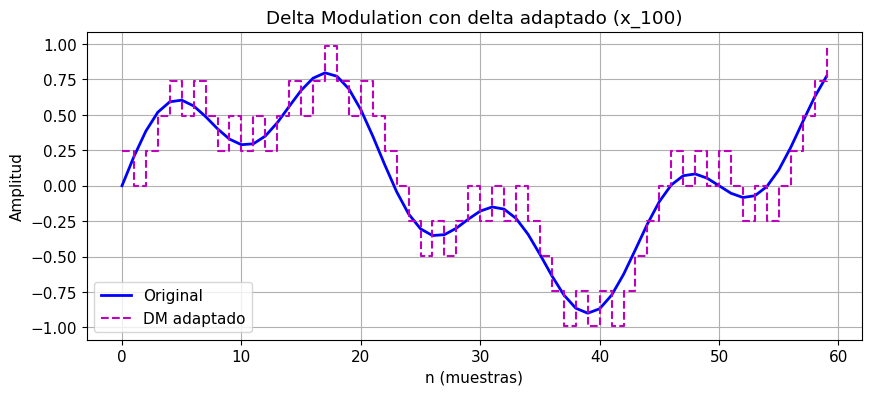

--- Señal x_400 ---
Delta adaptado: 0.0630
MSE: 0.001288
SQNR: 22.55 dB



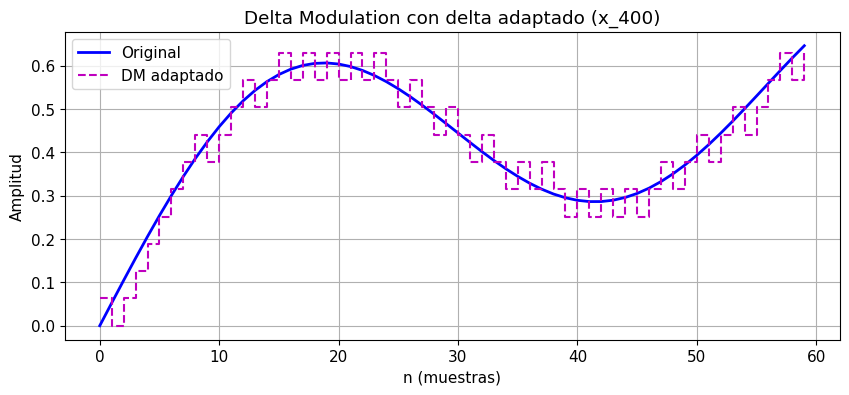

In [59]:
#demostración 1.
# Señales de prueba: x_100 y x_400
for x_sig, Fs, name in [(x_100, F_s100, "x_100"), (x_400, F_s400, "x_400")]:
    # Calcula la pendiente máxima y define delta adaptado
    max_slope = np.max(np.abs(np.diff(x_sig)))
    delta_adapt = 1.2 * max_slope

    # Aplica Delta Modulation con delta adaptado
    x_dm_adapt, bits_dm_adapt = delta_modulation(x_sig, delta_adapt)

    # Calcula métricas
    MSE_dm_adapt, SQNR_dm_adapt = calcular_metricas(x_sig, x_dm_adapt)

    # Resultados
    print(f"--- Señal {name} ---")
    print(f"Delta adaptado: {delta_adapt:.4f}")
    print(f"MSE: {MSE_dm_adapt:.6f}")
    print(f"SQNR: {SQNR_dm_adapt:.2f} dB\n")

    # Visualización (primeras 60 muestras)
    plt.figure(figsize=(10,4))
    plt.plot(x_sig[:60], 'b-', label='Original', linewidth=2)
    plt.plot(x_dm_adapt[:60], 'm--', label='DM adaptado', drawstyle="steps-post", linewidth=1.5)
    plt.title(f"Delta Modulation con delta adaptado ({name})")
    plt.xlabel("n (muestras)")
    plt.ylabel("Amplitud")
    plt.legend()
    plt.grid(True)
    plt.show()

`Observamos que la DM adaptada sigue mejor la forma de la señal que la DM con Δ fijo. También vemos menos slope overload (no sigue la pendiente de la señal) en zonas con cambios rápidos. Y la reconstrucción se aproxima más a la original, aumentando el SQNR.`

---
### 2. DM adaptativo (ADM)
Implementa un $\Delta$ que varíe: si el bit anterior fue igual al actual, duplica $\Delta$; si no, divídelo por 2. ¿Mejora el seguimiento de la señal?

`Sí, la DM adaptativa mejora el seguimiento de la señal. Al variar Δ según la tendencia, puede subir rápido cuando la señal cambia rápido y reducir el paso en zonas planas, evitando picos innecesarios y ruido granular. Esto produce una reconstrucción más fiel y un SQNR mayor.`

Delta inicial: 0.04
MSE: 0.112120, SQNR: 3.15 dB


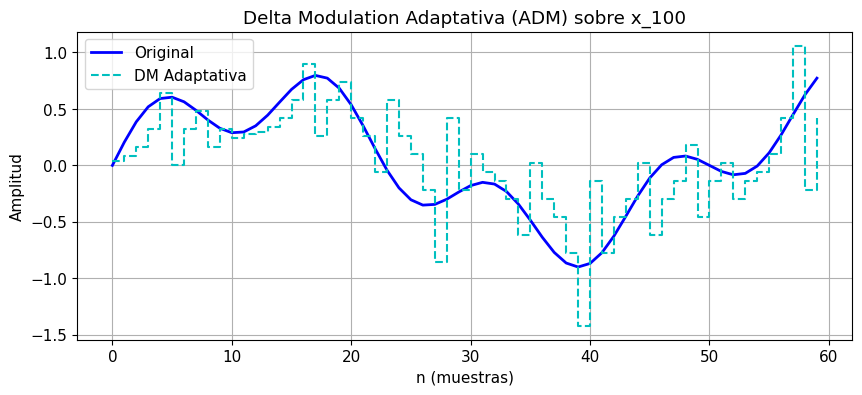

In [60]:
#demostración 2.
# === Delta Modulation Adaptativa (ADM) ===
def delta_mod_adaptativa(x, delta_init):
    """
    Delta Modulation con Δ adaptativo:
    - Si el bit actual = bit anterior: Δ se duplica
    - Si el bit cambia: Δ se divide por 2

    Parámetros:
        x: señal original
        delta_init: Δ inicial

    Retorna:
        x_q: señal reconstruida
        bits: secuencia de bits
    """
    N = len(x)
    x_q = np.zeros(N)
    bits = np.zeros(N, dtype=int)
    delta = delta_init

    for i in range(N):
        x_prev = x_q[i-1] if i > 0 else 0

        # Determina el bit
        if x[i] >= x_prev:
            bit = 1
            x_q[i] = x_prev + delta
        else:
            bit = 0
            x_q[i] = x_prev - delta

        # Ajusta delta según tendencia
        if i > 0:
            if bit == bits[i-1]:
                delta *= 2
            else:
                delta /= 2

        bits[i] = bit

    return x_q, bits

# --- Prueba visual para x_100 ---
delta_init = 0.04
x_adapt, bits_adapt = delta_mod_adaptativa(x_100, delta_init)
MSE_adapt, SQNR_adapt = calcular_metricas(x_100, x_adapt)

print(f"Delta inicial: {delta_init}")
print(f"MSE: {MSE_adapt:.6f}, SQNR: {SQNR_adapt:.2f} dB")

# Visualización (primeras 60 muestras)
plt.figure(figsize=(10,4))
plt.plot(x_100[:60], 'b-', label='Original', linewidth=2)
plt.plot(x_adapt[:60], 'c--', label='DM Adaptativa', drawstyle="steps-post", linewidth=1.5)
plt.title("Delta Modulation Adaptativa (ADM) sobre x_100")
plt.xlabel("n (muestras)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

`Observamos que la señal ADM sigue mejor los cambios rápidos que la DM con Δ fijo. También que en zonas planas, los cambios de Δ reducen los picos innecesarios y el ruido granular. Y comparamos visualmente el seguimiento y emos que es más fiel a la señal original.`

---

## 📚 Resumen de conceptos clave

| Concepto | Definición corta |
|----------|------------------|
| **PCM** | Pulse Code Modulation: familia de métodos de codificación digital |
| **LPCM** | Linear PCM: cuantifica cada muestra directamente ($B$ bits/muestra) |
| **DPCM** | Differential PCM: cuantifica el error de predicción ($B$ bits/muestra) |
| **DM** | Delta Modulation: DPCM con 1 bit (solo subir/bajar) |
| **Predictor** | Estima la muestra actual a partir de las anteriores |
| **Correlación temporal** | Muestras consecutivas parecidas → error de predicción pequeño |
| **Régimen binario ($R_b$)** | $B \times F_s$ bits/segundo |
| **Granular noise** | Error en DM con $\Delta$ demasiado grande |
| **Slope overload** | Error en DM con $\Delta$ demasiado pequeño |
| **ADPCM** | DPCM con paso adaptativo (varía $\Delta$ según la señal) |

---

**Fin del Taller 4**

*Este taller demuestra que explotar la redundancia temporal de una señal permite representarla con menos bits. En el Taller 5 veremos cómo la **entropía** cuantifica el límite teórico de compresión.*